# TP n°3
Etude de l'intérêt de l'ACP et de la régularisation
On se focalise sur la régression softmax

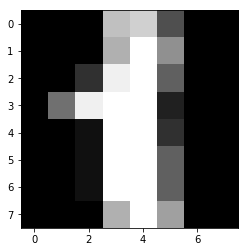

In [1]:
%matplotlib inline

#On commence par importer des modules basique Python
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import matplotlib as mpl

from sklearn import datasets
from sklearn.preprocessing import StandardScaler

data=datasets.load_digits()
X=data.data
y=data.target
n_class=np.max(y)-np.min(y)+1
(n,p)=X.shape

#Cette fois, on prend toutes les classes

#On affiche un exemple du dataset
mpl.pyplot.imshow(np.reshape(X[1,:],(8,8)), cmap='gray', interpolation="nearest")

On reprend aussi le principe d'une validation croisée à $k=10$ plis.

In [6]:
from sklearn.model_selection import KFold
print(X.shape)
#Réduction et Centrage made in sklearn
X = StandardScaler().fit_transform(X)

kf = KFold(n_splits=10,shuffle=True)
for train, test in kf.split(X):
    X_train = X[train,:]
    y_train = y[train]
    X_test = X[test,:]
    y_test = y[test]
    print(X_train.shape , X_test.shape)

(1797, 64)
(1617, 64) (180, 64)
(1617, 64) (180, 64)
(1617, 64) (180, 64)
(1617, 64) (180, 64)
(1617, 64) (180, 64)
(1617, 64) (180, 64)
(1617, 64) (180, 64)
(1618, 64) (179, 64)
(1618, 64) (179, 64)
(1618, 64) (179, 64)


## Questions
* utiliser la méthode `fit` de la classe `LogisticRegression` de `sklearn` pour entraîner une régression softmax
* utiliser la méthode `predict` sur l'ensemble de test pour calculer les erreurs pli par pli
* moyenner ces erreurs sur les $k=10$ plis

In [7]:
from sklearn.linear_model import LogisticRegression

clf1 = LogisticRegression(C=1e4);

err1 = []
for train, test in kf.split(X):
    X_train = X[train,:]
    y_train = y[train]
    X_test = X[test,:]
    y_test = y[test]
    
    clf1.fit(X_train,y_train)   
    
    y1 = clf1.predict(X_test)

    n_test = y_test.shape[0]
    err1.append(1 - np.sum(y1==y_test).astype(float)/n_test)


print (np.mean(err1))
print(err1)

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed

0.06068280571073866
[0.0444444444444444, 0.06666666666666665, 0.050000000000000044, 0.02777777777777779, 0.0444444444444444, 0.07777777777777772, 0.06666666666666665, 0.05586592178770955, 0.11173184357541899, 0.06145251396648044]


## Questions
* C'est le paramètre `C` dans l'appel du constructeur `LogisticRegression` qui correspond à l'hyperparamètre régulant l'influence d'une pénalité $L_2$. Faire, une boucle sur `C` allant de 0.1 à 10 au pas de 0.2 et tracer l'evoluation de l'erreur de test moyenne.

[1.00000000e-04 1.60371874e-04 2.57191381e-04 4.12462638e-04
 6.61474064e-04 1.06081836e-03 1.70125428e-03 2.72833338e-03
 4.37547938e-03 7.01703829e-03 1.12533558e-02 1.80472177e-02
 2.89426612e-02 4.64158883e-02 7.44380301e-02 1.19377664e-01
 1.91448198e-01 3.07029063e-01 4.92388263e-01 7.89652287e-01
 1.26638017e+00 2.03091762e+00 3.25702066e+00 5.22334507e+00
 8.37677640e+00 1.34339933e+01 2.15443469e+01 3.45510729e+01
 5.54102033e+01 8.88623816e+01 1.42510267e+02 2.28546386e+02
 3.66524124e+02 5.87801607e+02 9.42668455e+02 1.51177507e+03
 2.42446202e+03 3.88815518e+03 6.23550734e+03 1.00000000e+04]


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed

1


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed

2


...

38


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed

39


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed

40
[0.13855058969584108, 0.13301365611421478, 0.12301055245189323, 0.1185195530726257, 0.10294847920546246, 0.09237430167597767, 0.07900372439478584, 0.0729205462445686, 0.06731843575418994, 0.06509931719428927, 0.06119490999379266, 0.05341402855369336, 0.055080695220360035, 0.04786778398510242, 0.04508379888268155, 0.0428429546865301, 0.04061142147734326, 0.04006828057107385, 0.04005896958410924, 0.036719428926132815, 0.03503414028553693, 0.03561142147734325, 0.03341092489137183, 0.03393234016139046, 0.036728739913097455, 0.03339230291744257, 0.037858472998137806, 0.04229360645561764, 0.04451582867783986, 0.042290502793296124, 0.04009931719428926, 0.04950962135319677, 0.048407821229050296, 0.05621663563004346, 0.04675046554934824, 0.05675046554934822, 0.06011483550589697, 0.06122594661700807, 0.061790813159528245, 0.0651024208566108]


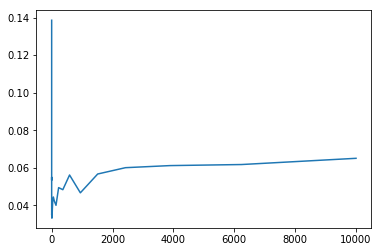

In [11]:
err1_ave=[]
#2^-6 2**-5 2**-4 .... 2**7
all_C = np.logspace(-4,4,40)
print(all_C)
idxC=0;
for C in all_C:
    clf1 = LogisticRegression(C=C);
    err1 = []
    for train, test in kf.split(X):
        X_train = X[train,:]
        y_train = y[train]
        X_test = X[test,:]
        y_test = y[test]

        clf1.fit(X_train,y_train)   

        y1 = clf1.predict(X_test)

        n_test = y_test.shape[0]
        err1.append(1 - np.sum(y1==y_test).astype(float)/n_test)

    err1_ave.append(np.mean(err1))
    idxC = idxC+1;
    print(idxC)
print(err1_ave)
plt.figure()
plt.plot(all_C,err1_ave)

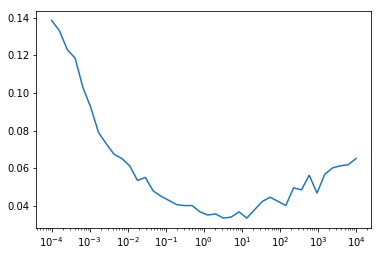

In [12]:
plt.figure()
plt.semilogx(all_C,err1_ave)

## Questions
* A l'aide de la classe `PCA`, opérer une réduction à $p=53$ dimensions
* Relancer un apprentissage de la régression softmax (avec `C`=3.6)

In [21]:
from sklearn.decomposition import PCA
X=data.data
X = StandardScaler().fit_transform(X)

Nb_comp = np.arange(10,55,5)
err_PCA=[]
for N in Nb_comp:

    pca = PCA(n_components=N)
    Xtrans = pca.fit_transform(X)
    clf1 = LogisticRegression(C=3.6);

    err1 = []
    for train, test in kf.split(X):
        #X_train = pca.fit_transform(X[train,:])
        X_train = Xtrans[train,:]    
        y_train = y[train]
        #X_test = pca.transform(X[test,:])
        X_test = Xtrans[test,:]    
        y_test = y[test]

        clf1.fit(X_train,y_train)   

        y1 = clf1.predict(X_test)

        n_test = y_test.shape[0]
        err1.append(1 - np.sum(y1==y_test).astype(float)/n_test)


    print(np.mean(err1))
    err_PCA.append(np.mean(err1))


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed

0.129130974549969


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed

0.0695592799503414


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed

...

0.041719428926132854


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed

0.03952203600248293


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed

0.03559590316573556


In [22]:
print(err_PCA)



[0.129130974549969, 0.0695592799503414, 0.060074487895716955, 0.056204220980757294, 0.0473060211049038, 0.04341092489137181, 0.041719428926132854, 0.03952203600248293, 0.03559590316573556]
